start

In [28]:
# %%
# Importy podstawowe
import numpy as np
import matplotlib.pyplot as plt

# TOPFARM
from topfarm import TopFarmProblem
from topfarm.easy_drivers import EasyScipyOptimizeDriver
from topfarm.cost_models.py_wake_wrapper import PyWakeAEPCostModelComponent

# Ograniczenia
from topfarm.constraint_components.spacing import SpacingConstraint

# PyWake: dane przykładowe i model wake
from py_wake.examples.data.iea37._iea37 import IEA37_WindTurbines, IEA37Site
from py_wake.deficit_models.noj import NOJ

print("Imports OK")


Imports OK


In [29]:
# %%
# Definicja sit i turbin
site = IEA37Site(16)
wt = IEA37_WindTurbines()
wfm = NOJ(site, wt)

# Początkowe pozycje turbin (2 turbiny)
x0 = [0, 500]
y0 = [0, 0]

# liczna turbin
n_wt = len(x0)

print(f"Site, turbines and wake model ready ({n_wt} turbines)")


Site, turbines and wake model ready (2 turbines)


In [30]:
# %%
# komponent kosztu AEP z finite differences (fd) zamiast autograd
cost_comp = PyWakeAEPCostModelComponent(
    windFarmModel=wfm,  # Model farmy
    n_wt=n_wt,          # liczba turbin
    grad_method="fd"    # <- zmiana z 'autograd' na 'fd' dla stabilności
)

print("AEP cost component ready (grad_method='fd')")


AEP cost component ready (grad_method='fd')


In [31]:
# %%
# komponent kosztu AEP bez jawnego grad_method
cost_comp = PyWakeAEPCostModelComponent(
    windFarmModel=wfm,  # Model farmy
    n_wt=n_wt           # liczba turbin
)

print("AEP cost component ready (using default gradient method)")



AEP cost component ready (using default gradient method)


In [32]:
# %%
# driver i ograniczenia
spacing = SpacingConstraint(min_spacing=300)
driver = EasyScipyOptimizeDriver(optimizer="SLSQP", maxiter=100)  # zwiększamy iteracje

# problem optymalizacji
opt_problem = TopFarmProblem(
    design_vars={"x": x0, "y": y0},
    cost_comp=cost_comp,
    constraints=[spacing],
    driver=driver
)

# Uruchamiamy optymalizację
result = opt_problem.optimize(disp=True)

# Obsługa różnych wersji TopFarm2
if isinstance(result, tuple):
    # starsze wersje mogą zwracać tuple (cost, state)
    if len(result) >= 2:
        opt_cost, opt_state = result[0], result[1]
    else:
        opt_cost, opt_state = result[0], result[0]
else:
    # nowsze wersje zwracają obiekt state
    opt_state = result
    opt_cost = result.cost

# Wypisujemy wyniki
print("Optimized AEP:", -opt_cost)
print("New x:", opt_state["x"])
print("New y:", opt_state["y"])





Optimization terminated successfully    (Exit mode 0)
            Current function value: -58.85894611111829
            Iterations: 55
            Function evaluations: 55
            Gradient evaluations: 55
Optimization Complete
-----------------------------------
Optimized in	1.234s
Optimized AEP: 58.85894611111829
New x: [-7900262.92185055  7900762.92185056]
New y: [ 423001.17381108 -423001.17381108]


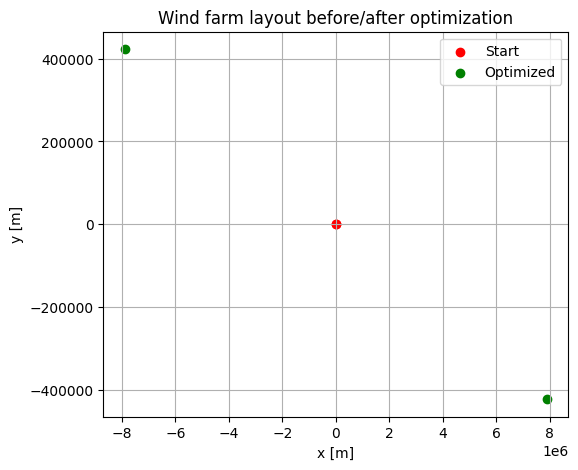

In [33]:
# %%
plt.figure(figsize=(6,5))
plt.scatter(x0, y0, label="Start", c="red")
plt.scatter(opt_state["x"], opt_state["y"], label="Optimized", c="green")
plt.legend()
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Wind farm layout before/after optimization")
plt.grid(True)
plt.show()
